In [1]:
print("jordan")

jordan


In [2]:
%matplotlib inline
import os
os.environ["BOKEH_ALLOW_WS_ORIGIN"] = "*"
from lightkurve import search_targetpixelfile
import matplotlib.pyplot as plt
pixelfile = search_targetpixelfile("KIC 8462852", quarter=16).download(quality_bitmask='hardest');

C:\Users\hamsul1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
pixelfile.animate()

In [4]:
pixelfile.interact()

In [5]:
lc = pixelfile.to_lightcurve(aperture_mask='all')

In [6]:
lc.time, lc.flux

(<Time object: scale='tdb' format='bkjd' value=[1472.11777934 1472.13821223 1472.15864492 ... 1557.89718798 1557.9380561
  1557.95849016]>,
 <Quantity [258645.03, 258660.05, 258690.08, ..., 258929.86, 258884.66,
            258865.6 ] electron / s>)

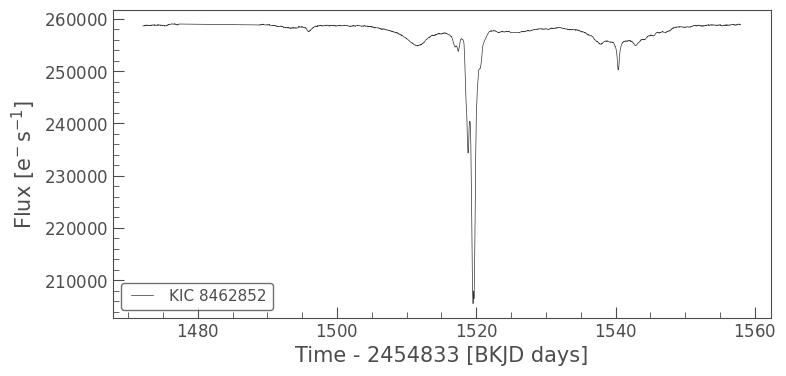

In [7]:
lc.plot();

In [8]:
pixelFile = search_targetpixelfile('KIC 6922244', quarter=4, cadence = 'long').download()

In [9]:
lc = pixelFile.to_lightcurve(aperture_mask=pixelFile.pipeline_mask)

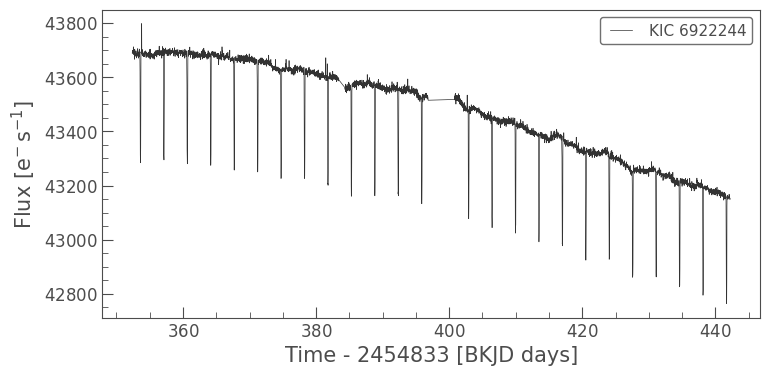

In [10]:
lc.plot();

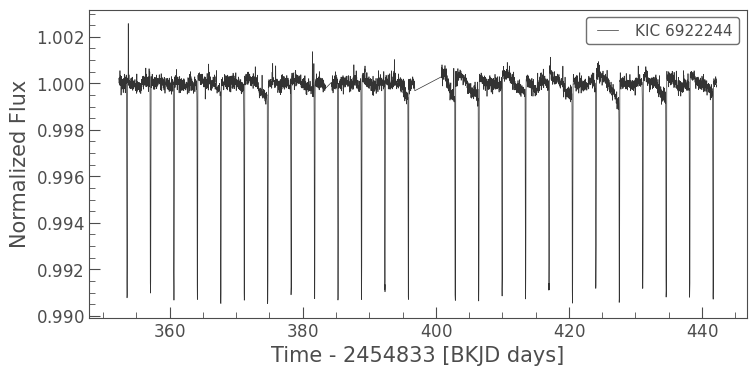

In [11]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

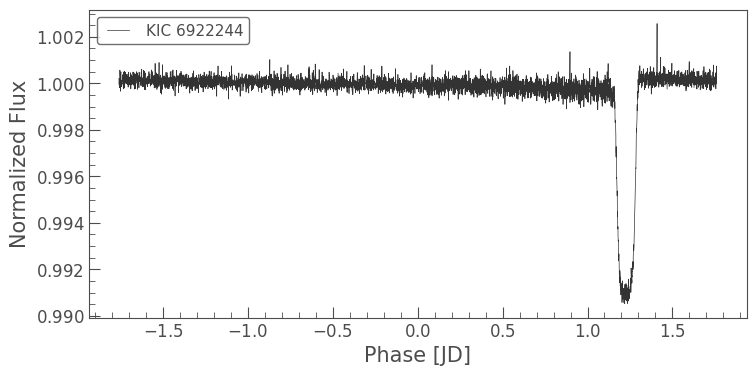

In [12]:
folded_lc = flat_lc.fold(period=3.5225)
folded_lc.plot();

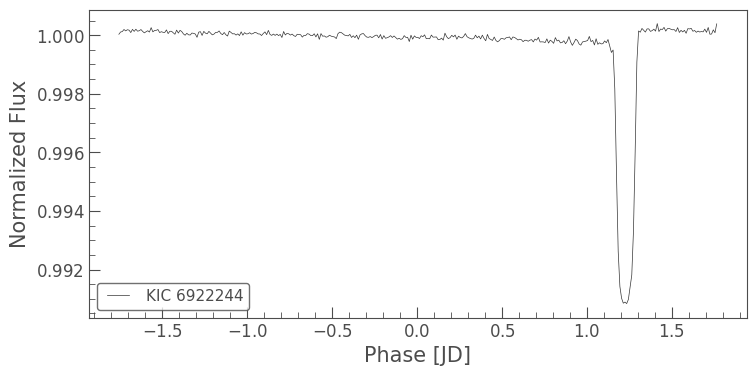

In [13]:
binned_lc = folded_lc.bin(time_bin_size=0.01)
binned_lc.plot();

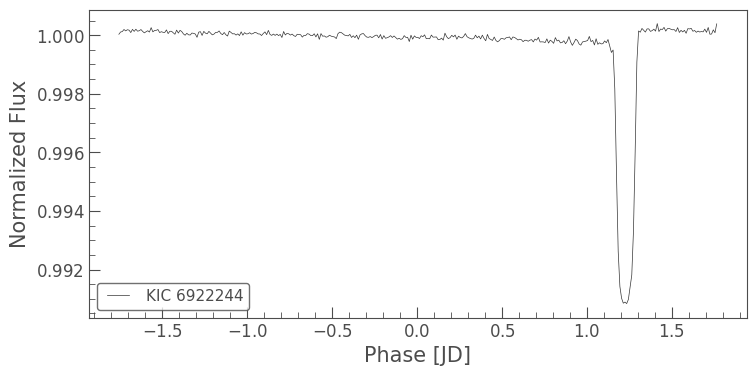

In [14]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(time_bin_size=0.01).plot();

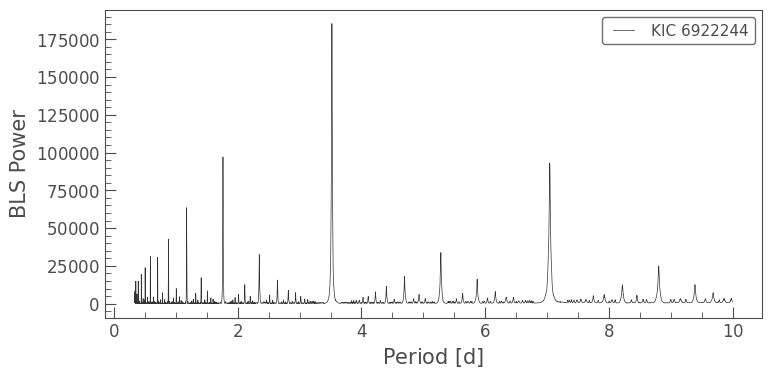

In [15]:
import numpy as np
periodogram = flat_lc.to_periodogram(method="bls", period=np.arange(0.333, 10, 0.001))
periodogram.plot();

In [16]:
best_fit_period = periodogram.period_at_max_power
print('Best fit period: {:.5f}'.format(best_fit_period))

Best fit period: 3.52200 d
